No se encontró archivo real. Generando 400 clientes lógicos...

--- VISTA LÓGICA DE LOS DATOS ---
   Edad  Horas  Compra
0    55   1.13       1
1    30   0.83       1
2    26   3.83       1
3    27   0.64       0
4    29   1.00       0
5    23   6.59       1
6    33   5.27       0
7    18   6.30       1
8    34   5.79       1
9    19   2.29       0

Total que compraron: 278 de 400
Total que NO compraron: 122 de 400
Promedio edad: 38.6, Promedio horas: 4.3

--- ENTRENANDO ---
Iter 0: loss=0.693, w=[0.01 0.02], b=0.02
Iter 50: loss=0.535, w=[0.37 0.5 ], b=0.59
Iter 100: loss=0.514, w=[0.49 0.68], b=0.81
Iter 150: loss=0.510, w=[0.55 0.77], b=0.92
Iter 200: loss=0.508, w=[0.59 0.82], b=0.97
Iter 250: loss=0.508, w=[0.6  0.85], b=1.00

Final: loss=0.508, w=[0.62 0.86], b=1.02


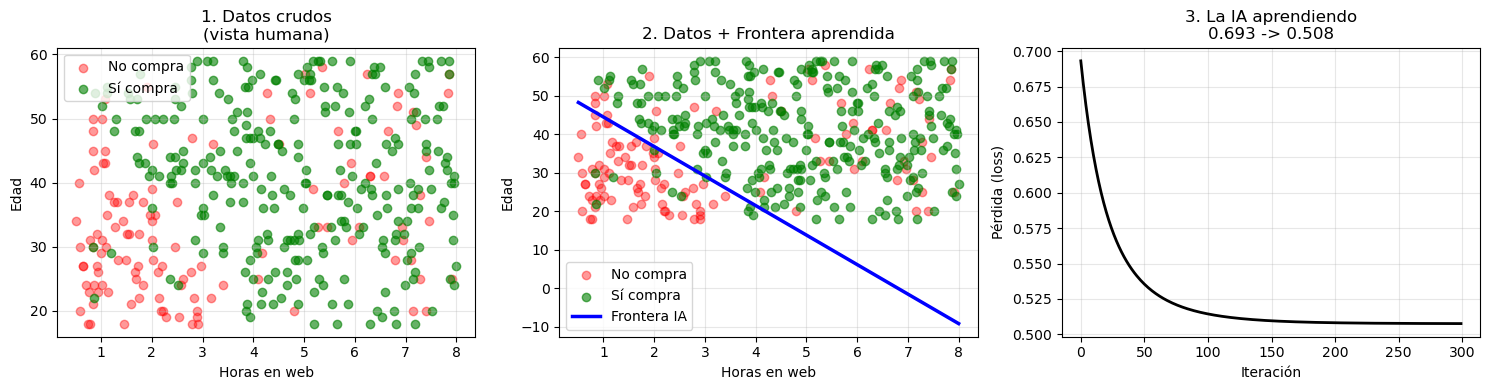


--- PRUEBA FINAL ---
Cliente 45 años, 6h -> 88.3% -> COMPRA
Cliente 22 años, 1h -> 23.7% -> NO COMPRA
Cliente 30 años, 7.5h -> 86.3% -> COMPRA
Cliente 50 años, 2h -> 66.5% -> COMPRA


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ================= ETAPA 1: CARGA DE DATOS =================
# Si existe tu archivo real lo usa, si no, genera los 400 lógicos que pediste

ruta_real = "../data/empresaX.csv"

if os.path.exists(ruta_real):
    print(f"Cargando datos reales de {ruta_real}")
    df = pd.read_csv(ruta_real)
    X_raw = df.drop(columns=['Compra']).values
    y = df['Compra'].values
    edad = X_raw[:,0] # para gráficas, asume col 0 es edad
    tiempo = X_raw[:,1] # col 1 es horas
else:
    print("No se encontró archivo real. Generando 400 clientes lógicos...")
    np.random.seed(1)
    edad = np.random.randint(18, 60, 400)
    tiempo = np.random.uniform(0.5, 8, 400)
    prob_real = 1 / (1 + np.exp(-(0.08*edad + 0.9*tiempo - 5)))
    compra = (prob_real > 0.5).astype(int)
    compra = np.where(np.random.rand(400) < 0.1, 1-compra, compra)
    df = pd.DataFrame({'Edad': edad, 'Horas': np.round(tiempo,2), 'Compra': compra})
    X_raw = np.vstack([edad, tiempo]).T
    y = compra

# ================= ETAPA 2: VER LOS DATOS () =================
print("\n--- VISTA LÓGICA DE LOS DATOS ---")
print(df.head(10))
print(f"\nTotal que compraron: {y.sum()} de {len(y)}")
print(f"Total que NO compraron: {len(y) - y.sum()} de {len(y)}")
print(f"Promedio edad: {df['Edad'].mean():.1f}, Promedio horas: {df['Horas'].mean():.1f}")

# ================= ETAPA 3: PREPARACIÓN PARA LA IA =================
# Normalización automática sirve para 2 o 20 columnas
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

w = np.zeros(X.shape[1])
b = 0.0
lr = 0.1
losses = []

def sigmoid(z):
    return 1/(1+np.exp(-z))

# ================= ETAPA 4: ENTRENAMIENTO =================
print("\n--- ENTRENANDO ---")
for i in range(300):
    z = X @ w + b
    p = sigmoid(z)
    loss = -np.mean(y*np.log(p+1e-9) + (1-y)*np.log(1-p+1e-9))
    losses.append(loss)
    error = p - y
    dw = X.T @ error / len(y)
    db = np.mean(error)
    w -= lr * dw
    b -= lr * db
    if i % 50 == 0:
        print(f"Iter {i}: loss={loss:.3f}, w={np.round(w,2)}, b={b:.2f}")

print(f"\nFinal: loss={losses[-1]:.3f}, w={np.round(w,2)}, b={b:.2f}")

# ================= ETAPA 5: GRÁFICAS () =================
plt.figure(figsize=(15, 4))

# Gráfica 1: Datos solos, como los vería un humano contando a mano
plt.subplot(1,3,1)
plt.scatter(tiempo[y==0], edad[y==0], c='red', alpha=0.4, label='No compra')
plt.scatter(tiempo[y==1], edad[y==1], c='green', alpha=0.6, label='Sí compra')
plt.xlabel("Horas en web"); plt.ylabel("Edad")
plt.title("1. Datos crudos\n(vista humana)")
plt.legend(); plt.grid(True, alpha=0.3)

# Gráfica 2: Datos + la línea azul que aprendió la IA
plt.subplot(1,3,2)
plt.scatter(tiempo[y==0], edad[y==0], c='red', alpha=0.4, label='No compra')
plt.scatter(tiempo[y==1], edad[y==1], c='green', alpha=0.6, label='Sí compra')
# Solo si tenemos 2 columnas podemos dibujar la frontera
if X.shape[1] == 2:
    t_vals = np.linspace(tiempo.min(), tiempo.max(), 100)
    # despeje de la frontera: w0*edad_norm + w1*tiempo_norm + b = 0
    edad_line_norm = -(w[1]*(t_vals - X_mean[1])/X_std[1] + b) / w[0]
    edad_line = edad_line_norm * X_std[0] + X_mean[0]
    plt.plot(t_vals, edad_line, 'b-', linewidth=2.5, label='Frontera IA')
plt.xlabel("Horas en web"); plt.ylabel("Edad")
plt.title("2. Datos + Frontera aprendida")
plt.legend(); plt.grid(True, alpha=0.3)

# Gráfica 3: Como baja el error
plt.subplot(1,3,3)
plt.plot(losses, color='black', linewidth=2)
plt.xlabel("Iteración"); plt.ylabel("Pérdida (loss)")
plt.title("3. La IA aprendiendo\n0.693 -> 0.508")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================= ETAPA 6: PRUEBA FINAL =================
print("\n--- PRUEBA FINAL ---")
def predecir(edad_p, tiempo_p):
    x = np.array([edad_p, tiempo_p])
    x_norm = (x - X_mean[:2]) / X_std[:2]
    prob = sigmoid(x_norm @ w[:2] + b)
    return prob

for e, t in [(45,6), (22,1), (30,7.5), (50,2)]:
    prob = predecir(e,t)
    print(f"Cliente {e} años, {t}h -> {prob*100:.1f}% -> {'COMPRA' if prob>0.5 else 'NO COMPRA'}")

In [1]:
import os
print(os.getcwd())

C:\Users\juan carlos
